# YOLOv8m — Plastic Bottle & Aluminum Can Detector
**Dataset:** YOLO Waste Detection (ProjectVerba) — filtered to 2 classes  
**Goal:** Export `.pt` weights for local inference

---
### Before you start
1. Go to **Runtime → Change runtime type → T4 GPU**
2. Create a free account at [roboflow.com](https://roboflow.com)
3. Get your API key from **Roboflow → Settings → API**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls

drive  sample_data


In [ ]:
%cd /content/drive/MyDrive/

/content/drive/MyDrive


In [ ]:
!mkdir trash_detection

In [ ]:
%cd trash_detection

/content/drive/MyDrive/trash_detection


In [ ]:
!ls

YOLO-Waste-Detection-1


## Step 1 — Check GPU

In [ ]:
!nvidia-smi
# You should see a T4 (15GB VRAM). If not, go to Runtime → Change runtime type.

Sun Jun  7 10:18:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2 — Install dependencies

In [ ]:
!pip install ultralytics roboflow --quiet

import ultralytics
ultralytics.checks()  # Confirms GPU is visible to PyTorch

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


## Step 3 — Download & filter dataset from Roboflow

This downloads the full 42-class dataset, then we filter it down to only the 2 classes we care about.

In [ ]:
from roboflow import Roboflow

# Paste your Roboflow API key here
API_KEY = ""

rf = Roboflow(api_key=API_KEY)
project = rf.workspace("projectverba").project("yolo-waste-detection")
dataset = project.version(1).download("yolov8")

print(f"Dataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to YOLO-Waste-Detection-1 in yolov8:: 100%|██████████| 26220/26220 [05:41<00:00, 76.77it/s]


Dataset downloaded to: /content/drive/MyDrive/trash_detection/YOLO-Waste-Detection-1


## Step 4 — Filter labels to 2 classes only

The dataset has 42 classes. We keep only:
- Class `3` → `Plastic bottle`
- Class `10` → `Aluminum can`

All other annotations are dropped, and the YAML is rewritten.

In [ ]:
import os
import yaml
from pathlib import Path

DATASET_PATH = Path("/content/drive/MyDrive/trash_detection/YOLO-Waste-Detection-1")

# --- Read the original YAML to find class indices ---
yaml_path = DATASET_PATH / "data.yaml"
with open(yaml_path) as f:
    data = yaml.safe_load(f)

original_classes = data['names']
print("All classes:", original_classes)

# Find indices of our target classes (case-insensitive)
TARGET_CLASSES = ['Plastic bottle', 'Aluminum can']
target_indices = {}
for i, name in enumerate(original_classes):
    for target in TARGET_CLASSES:
        if name.lower() == target.lower():
            target_indices[i] = TARGET_CLASSES.index(target)

print(f"\nTarget class mapping (original_id -> new_id): {target_indices}")
# Should print something like {3: 0, 10: 1}

All classes: ['Aerosols', 'Aluminum can', 'Aluminum caps', 'Cardboard', 'Cellulose', 'Ceramic', 'Combined plastic', 'Container for household chemicals', 'Disposable tableware', 'Electronics', 'Foil', 'Furniture', 'Glass bottle', 'Iron utensils', 'Liquid', 'Metal shavings', 'Milk bottle', 'Organic', 'Paper bag', 'Paper cups', 'Paper shavings', 'Paper', 'Papier mache', 'Plastic bag', 'Plastic bottle', 'Plastic can', 'Plastic canister', 'Plastic caps', 'Plastic cup', 'Plastic shaker', 'Plastic shavings', 'Plastic toys', 'Postal packaging', 'Printing industry', 'Scrap metal', 'Stretch film', 'Tetra pack', 'Textile', 'Tin', 'Unknown plastic', 'Wood', 'Zip plastic bag']

Target class mapping (original_id -> new_id): {1: 1, 24: 0}


In [ ]:
def filter_labels(label_dir, target_indices):
    """
    For each .txt annotation file:
    - Keep only rows whose class_id is in target_indices
    - Remap class_id to new 0-based index
    - If a file becomes empty after filtering, delete it and its image
    """
    label_dir = Path(label_dir)
    if not label_dir.exists():
        return

    removed_images = 0
    kept_annotations = 0

    for label_file in label_dir.glob("*.txt"):
        with open(label_file) as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            class_id = int(parts[0])
            if class_id in target_indices:
                new_id = target_indices[class_id]
                new_lines.append(f"{new_id} {' '.join(parts[1:])}\n")

        if new_lines:
            with open(label_file, 'w') as f:
                f.writelines(new_lines)
            kept_annotations += len(new_lines)
        else:
            # No relevant annotations — remove label file and corresponding image
            label_file.unlink()
            for ext in ['.jpg', '.jpeg', '.png']:
                img_path = label_file.parent.parent / 'images' / (label_file.stem + ext)
                if img_path.exists():
                    img_path.unlink()
                    removed_images += 1

    print(f"  Kept {kept_annotations} annotations, removed {removed_images} images with no relevant labels")


for split in ['train', 'valid', 'test']:
    label_dir = DATASET_PATH / split / 'labels'
    print(f"Processing {split}...")
    filter_labels(label_dir, target_indices)

print("\nFiltering complete.")

Processing train...
  Kept 6546 annotations, removed 7494 images with no relevant labels
Processing valid...
  Kept 638 annotations, removed 697 images with no relevant labels
Processing test...
  Kept 315 annotations, removed 350 images with no relevant labels

Filtering complete.


In [ ]:
# Rewrite data.yaml with only our 2 classes
data['names'] = TARGET_CLASSES
data['nc'] = len(TARGET_CLASSES)

# Make sure paths are absolute (Colab needs this)
data['train'] = str(DATASET_PATH / 'train' / 'images')
data['val']   = str(DATASET_PATH / 'valid' / 'images')
data['test']  = str(DATASET_PATH / 'test'  / 'images')

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("Updated data.yaml:")
print(yaml.dump(data))

Updated data.yaml:
names:
- Plastic bottle
- Aluminum can
nc: 2
roboflow:
  license: CC BY 4.0
  project: yolo-waste-detection
  url: https://universe.roboflow.com/projectverba/yolo-waste-detection/dataset/1
  version: 1
  workspace: projectverba
test: /content/drive/MyDrive/trash_detection/YOLO-Waste-Detection-1/test/images
train: /content/drive/MyDrive/trash_detection/YOLO-Waste-Detection-1/train/images
val: /content/drive/MyDrive/trash_detection/YOLO-Waste-Detection-1/valid/images



In [ ]:
import shutil
shutil.copytree(
    "/content/drive/MyDrive/trash_detection/YOLO-Waste-Detection-1",
    "/content/YOLO-Waste-Detection-1"
)
DATASET_PATH = Path("/content/YOLO-Waste-Detection-1")
yaml_path = DATASET_PATH / "data.yaml"

## Step 5 — Verify dataset (sanity check)

Before wasting GPU time, confirm your data looks right.

In [ ]:
import glob

for split in ['train', 'valid', 'test']:
    imgs = len(glob.glob(str(DATASET_PATH / split / 'images' / '*')))
    lbls = len(glob.glob(str(DATASET_PATH / split / 'labels' / '*.txt')))
    print(f"{split:6s} → {imgs:4d} images, {lbls:4d} label files")

# Images and label counts should roughly match.
# Some images may have no annotations if the object wasn't present — that's fine.

train  → 3972 images, 3972 label files
valid  →  395 images,  395 label files
test   →  196 images,  196 label files


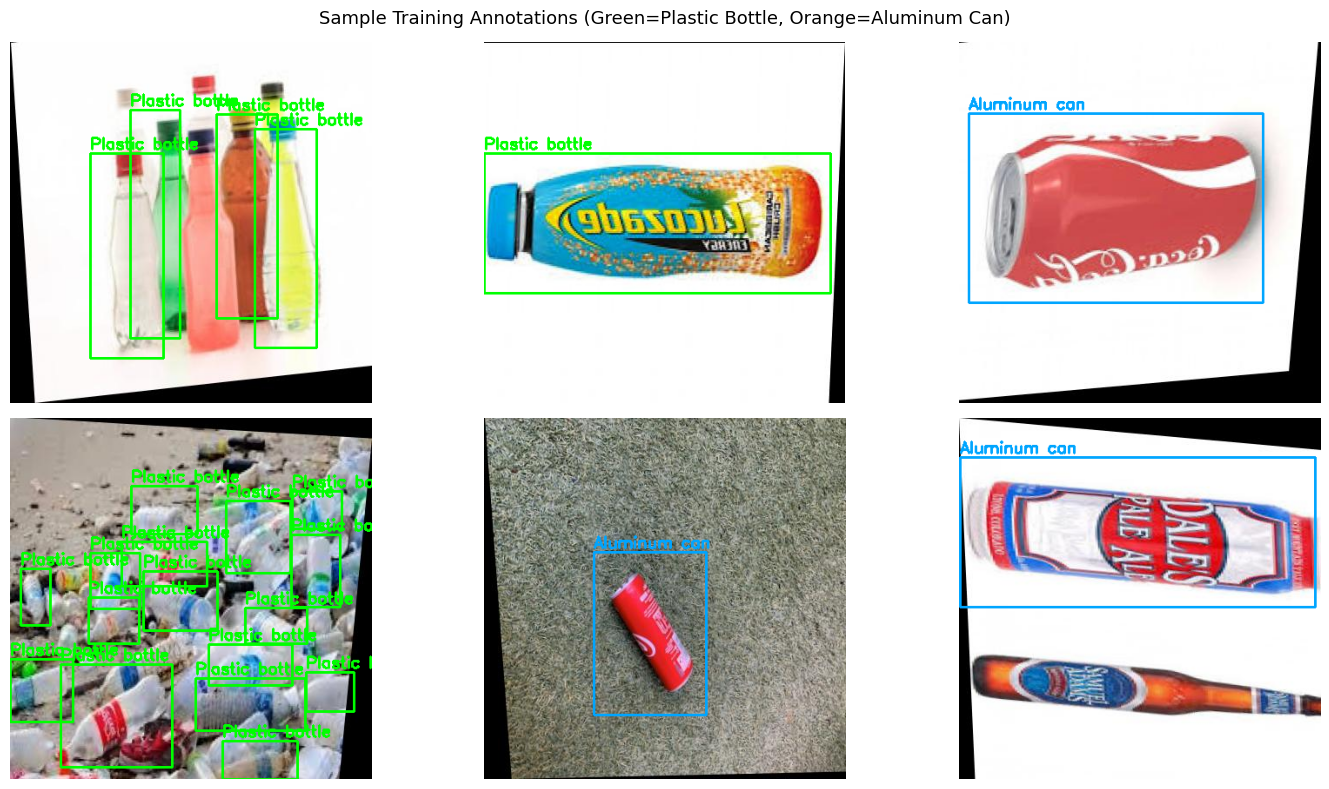

In [ ]:
# Visualize a few training samples to confirm annotations look correct
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import cv2
import numpy as np

COLOR_MAP = {0: (0, 255, 0), 1: (0, 165, 255)}  # Green=Plastic bottle, Orange=Aluminum can
CLASS_NAMES = TARGET_CLASSES

train_imgs = glob.glob(str(DATASET_PATH / 'train' / 'images' / '*'))
sample_imgs = random.sample(train_imgs, min(6, len(train_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_imgs):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    label_path = img_path.replace('images', 'labels').rsplit('.', 1)[0] + '.txt'
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                cls, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                color = COLOR_MAP[cls]
                cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
                cv2.putText(img, CLASS_NAMES[cls], (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    ax.imshow(img)
    ax.axis('off')

plt.suptitle('Sample Training Annotations (Green=Plastic Bottle, Orange=Aluminum Can)', fontsize=13)
plt.tight_layout()
plt.show()

## Step 6 — Train YOLOv8m

**Expected time on T4:** ~1.5–2 hrs for 50 epochs  
**VRAM usage:** ~8–10 GB (T4 has 15 GB, so we're fine)

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8m.pt')  # Downloads pretrained COCO weights (~52MB)

results = model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,          # Safe for T4. Increase to 32 if you have A100.
    patience=15,       # Early stopping: halt if no improvement for 15 epochs
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,          # Final LR = lr0 * lrf = 0.00001
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    mosaic=1.0,        # Mosaic augmentation (strong, good for small datasets)
    mixup=0.1,
    degrees=10.0,      # Rotation augmentation
    flipud=0.0,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    project='runs/train',
    name='recycle_v1',
    exist_ok=True,
    pretrained=True,   # Fine-tune from COCO weights, not scratch
    device=0,          # GPU 0
    verbose=True
)

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/YOLO-Waste-Detection-1/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=recycle_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=Tru

## Step 7 — Evaluate on test set

In [ ]:
# Load best weights from training
best_model = YOLO('/content/drive/MyDrive/trash_detection/runs/detect/runs/train/recycle_v1/weights/best.pt')

metrics = best_model.val(
    data=str(yaml_path),
    split='test',
    imgsz=640,
    conf=0.25,
    iou=0.6
)

print(f"\n=== Test Set Results ===")
print(f"mAP@50:      {metrics.box.map50:.4f}")
print(f"mAP@50-95:   {metrics.box.map:.4f}")
print(f"Precision:   {metrics.box.mp:.4f}")
print(f"Recall:      {metrics.box.mr:.4f}")
print(f"\nPer-class mAP@50:")
for i, name in enumerate(TARGET_CLASSES):
    print(f"  {name}: {metrics.box.ap50[i]:.4f}")

Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 10.1±20.7 ms, read: 2.7±2.6 MB/s, size: 23.9 KB)
val: Scanning /content/drive/MyDrive/trash_detection/YOLO-Waste-Detection-1/test/labels... 196 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 196/196 95.2it/s 2.1s
val: New cache created: /content/drive/MyDrive/trash_detection/YOLO-Waste-Detection-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.5it/s 8.6s
                   all        196        315      0.776      0.694       0.66      0.401
        Plastic bottle         38        123      0.611       0.46      0.387      0.207
          Aluminum can        158        192      0.941      0.927      0.932      0.595
Speed: 4.7ms preprocess, 25.6ms inference, 0.0ms loss, 3.7ms postprocess per image
Resu

## Step 8 — Plot training curves

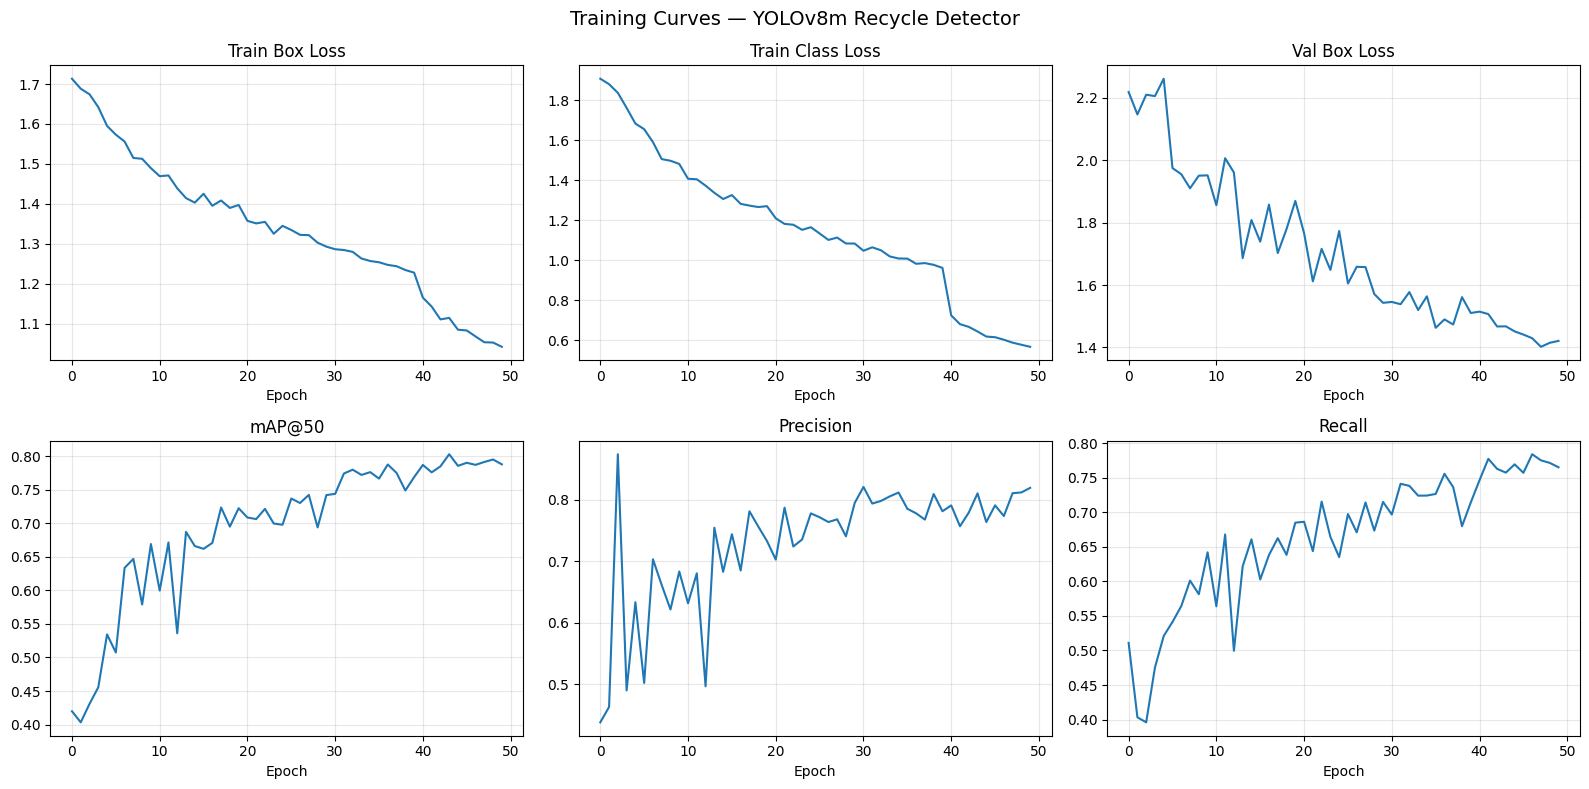

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = pd.read_csv('/content/drive/MyDrive/trash_detection/runs/detect/runs/train/recycle_v1/results.csv')
results_csv.columns = results_csv.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

plots = [
    ('train/box_loss',  'Train Box Loss',  axes[0][0]),
    ('train/cls_loss',  'Train Class Loss', axes[0][1]),
    ('val/box_loss',    'Val Box Loss',    axes[0][2]),
    ('metrics/mAP50(B)',   'mAP@50',          axes[1][0]),
    ('metrics/precision(B)', 'Precision',       axes[1][1]),
    ('metrics/recall(B)',    'Recall',          axes[1][2]),
]

for col, title, ax in plots:
    if col in results_csv.columns:
        ax.plot(results_csv[col])
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves — YOLOv8m Recycle Detector', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## Step 9 — Run inference on a test image


image 1/1 /content/YOLO-Waste-Detection-1/test/images/3c821bb2-R_1314_jpg.rf.7145291050ace5070ad194df1bd0ed22.jpg: 640x640 3 Plastic bottles, 37.0ms
Speed: 3.2ms preprocess, 37.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/trash_detection/runs/detect/runs/predict/test_sample-2


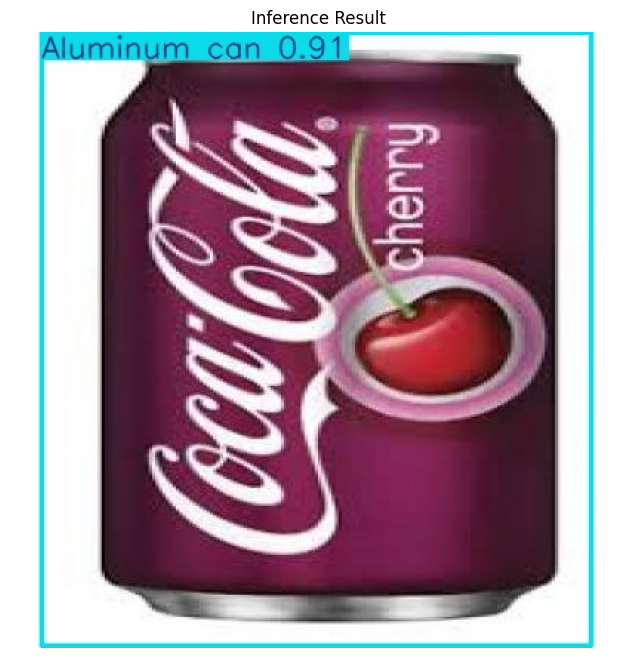

  Detected: Plastic bottle — confidence: 0.90
  Detected: Plastic bottle — confidence: 0.79
  Detected: Plastic bottle — confidence: 0.58


In [ ]:
import glob, random
from PIL import Image

# Pick a random test image
test_images = glob.glob(str(DATASET_PATH / 'test' / 'images' / '*'))
sample = random.choice(test_images)

results = best_model.predict(
    source=sample,
    conf=0.25,
    iou=0.6,
    save=True,
    project='runs/predict',
    name='test_sample'
)

# Display result
result_img_path = glob.glob('/content/drive/MyDrive/trash_detection/runs/detect/runs/predict/test_sample/*.jpg')[0]
img = Image.open(result_img_path)
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title('Inference Result')
plt.show()

# Print detections
for r in results:
    for box in r.boxes:
        cls = int(box.cls)
        conf = float(box.conf)
        print(f"  Detected: {TARGET_CLASSES[cls]} — confidence: {conf:.2f}")

## Step 10 — Export weights

Download `best.pt` to your local machine for inference.

In [ ]:
from google.colab import files
import shutil

# Copy best weights to a convenient location

shutil.copy('/content/drive/MyDrive/trash_detection/runs/detect/runs/train/recycle_v1/weights/best.pt', 'recycle_detector_best.pt')
shutil.copy('/content/drive/MyDrive/trash_detection/runs/detect/runs/train/recycle_v1/weights/last.pt', 'recycle_detector_last.pt')

# Download to local machine
files.download('recycle_detector_best.pt')

print("best.pt downloaded. Use this for inference.")
print("last.pt is available if you want to resume training later.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

best.pt downloaded. Use this for inference.
last.pt is available if you want to resume training later.


## Local Inference (run this on your machine after downloading)

```python
from ultralytics import YOLO
import cv2

model = YOLO('recycle_detector_best.pt')

# On a single image
results = model.predict('your_image.jpg', conf=0.25)
results[0].show()

# On webcam (stream=True for memory efficiency)
results = model.predict(source=0, stream=True, conf=0.25)
for r in results:
    frame = r.plot()
    cv2.imshow('Recycle Detector', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cv2.destroyAllWindows()
```

---
## Troubleshooting

| Problem | Fix |
|---|---|
| `CUDA out of memory` | Reduce `batch` from 16 → 8 |
| mAP not improving after 20 epochs | Reduce `lr0` to 0.0005, increase `patience` |
| Class indices not found | Print `original_classes` and manually set `target_indices = {X: 0, Y: 1}` |
| Runtime disconnects | Enable `exist_ok=True` (already set) and re-run Step 6; training resumes from last checkpoint |
| Very low recall on one class | That class is underrepresented — check annotation count per class after filtering |